

### Architecture
In this experiment, EfficientNet_B0 is applied and last layer is removed with single output for the pawpularity finetuning without metadata inclusion. Some very basic augmentation (horizontal flipping) is added.
Instead of MSE loss, Huber Loss is applied

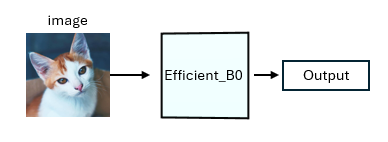

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
#  imports & setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image

main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp2_256_effB0_Hub")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp2"]
cfg["name"] = "exp2_256_effB0_Hub"
cfg["loss"] = "huber"

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

# id2idx = {id_: i for i, id_ in enumerate(df["Id"].values)}
start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp2_256_effB0_Hub: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[HUBER]: Loss=18.9686 | ValRMSE: 21.2202
Epoch 2/10 | Fold 1 | Train[HUBER]: Loss=13.3992 | ValRMSE: 20.3548
Epoch 3/10 | Fold 1 | Train[HUBER]: Loss=12.4037 | ValRMSE: 19.8244
Epoch 4/10 | Fold 1 | Train[HUBER]: Loss=11.7324 | ValRMSE: 19.7508
Epoch 5/10 | Fold 1 | Train[HUBER]: Loss=11.1024 | ValRMSE: 19.8153
Epoch 6/10 | Fold 1 | Train[HUBER]: Loss=10.6654 | ValRMSE: 19.7112
Epoch 7/10 | Fold 1 | Train[HUBER]: Loss=10.4265 | ValRMSE: 19.7201
Epoch 8/10 | Fold 1 | Train[HUBER]: Loss=10.0241 | ValRMSE: 19.7438
Epoch 9/10 | Fold 1 | Train[HUBER]: Loss=9.9252 | ValRMSE: 19.8196
Epoch 10/10 | Fold 1 | Train[HUBER]: Loss=9.7774 | ValRMSE: 19.7142
Fold 1 best RMSE: 19.7112

=== exp2_256_effB0_Hub: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[HUBER]: Loss=19.6779 | ValRMSE: 20.4749
Epoch 2/10 | Fold 2 | Train[HUBER]: Loss=13.4099 | ValRMSE: 19.4698
Epoch 3/10 | Fold 2 | Train[HUBER]: Loss=12.4741 | ValRMSE: 19.2025
Epoch 4/10 | Fold 2

In [4]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 19.7112 (n=1983)
Fold 2 OOF RMSE: 19.0830 (n=1983)
Fold 3 OOF RMSE: 18.4970 (n=1982)
Fold 4 OOF RMSE: 19.2511 (n=1982)
Fold 5 OOF RMSE: 19.3703 (n=1982)


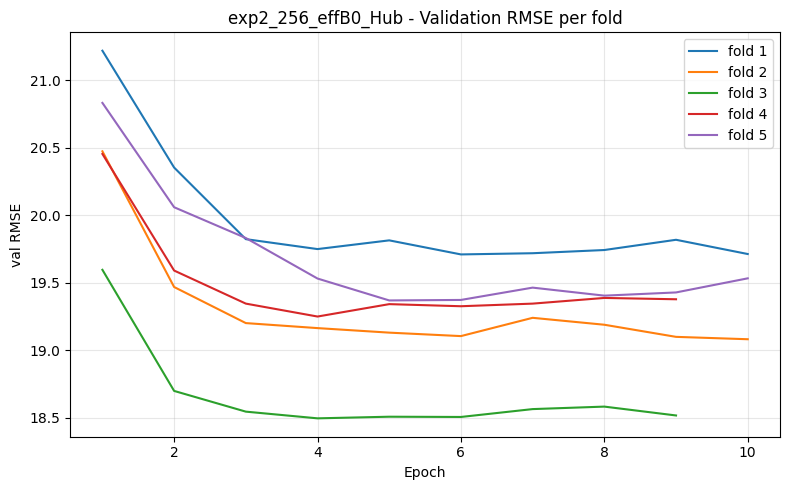

In [5]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="exp2_256_effB0_Hub")


In [6]:
# Worst error images 
errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()


,Id,fold,ytrue,oof_pred,abs_err
0,73f9e8a6d0926f7c5201f034406d986d,4,100,10.622715,89.377285
1,d221b46947fc086e7445590e2bd1e808,4,100,20.904247,79.095753
2,48a66727373de4e7fa7bb3331cd9acc8,3,96,18.813251,77.186749
3,e2ae437b18e6ca5261acc713ecda948f,4,100,24.570229,75.429771
4,054cef9194f1a4513dc0965893b589bf,3,2,76.834885,74.834885


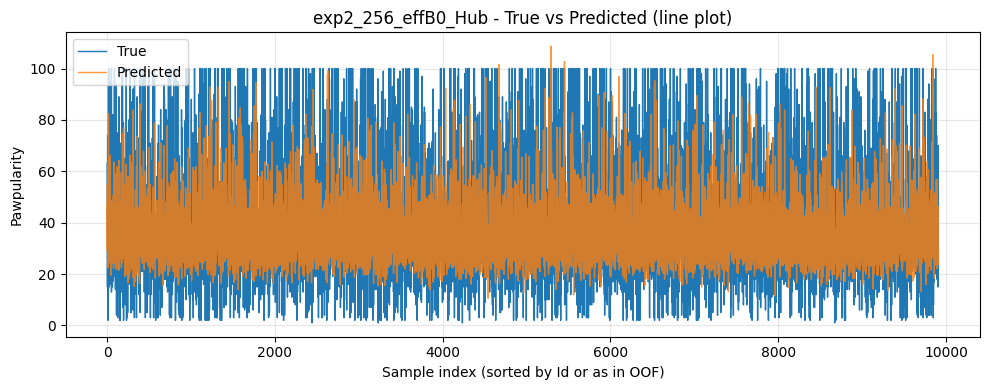

In [7]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="exp2_256_effB0_Hub")

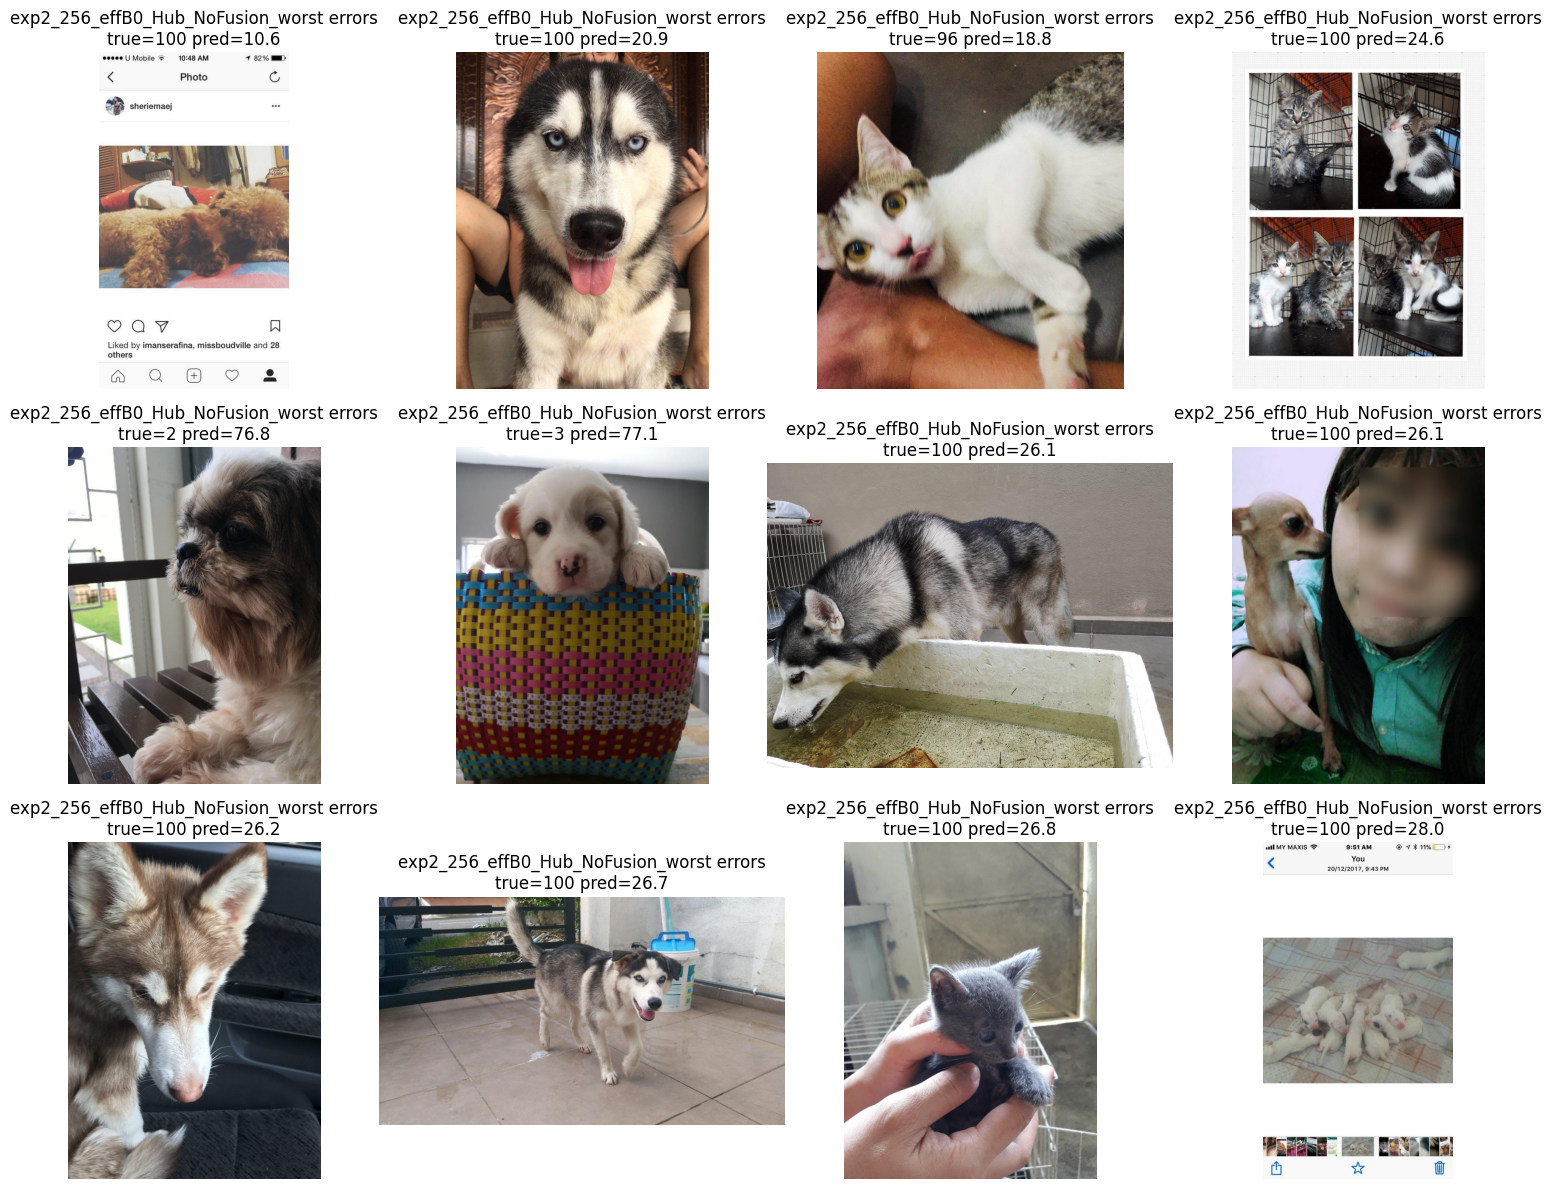

In [8]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp2_256_effB0_Hub_NoFusion_worst errors")

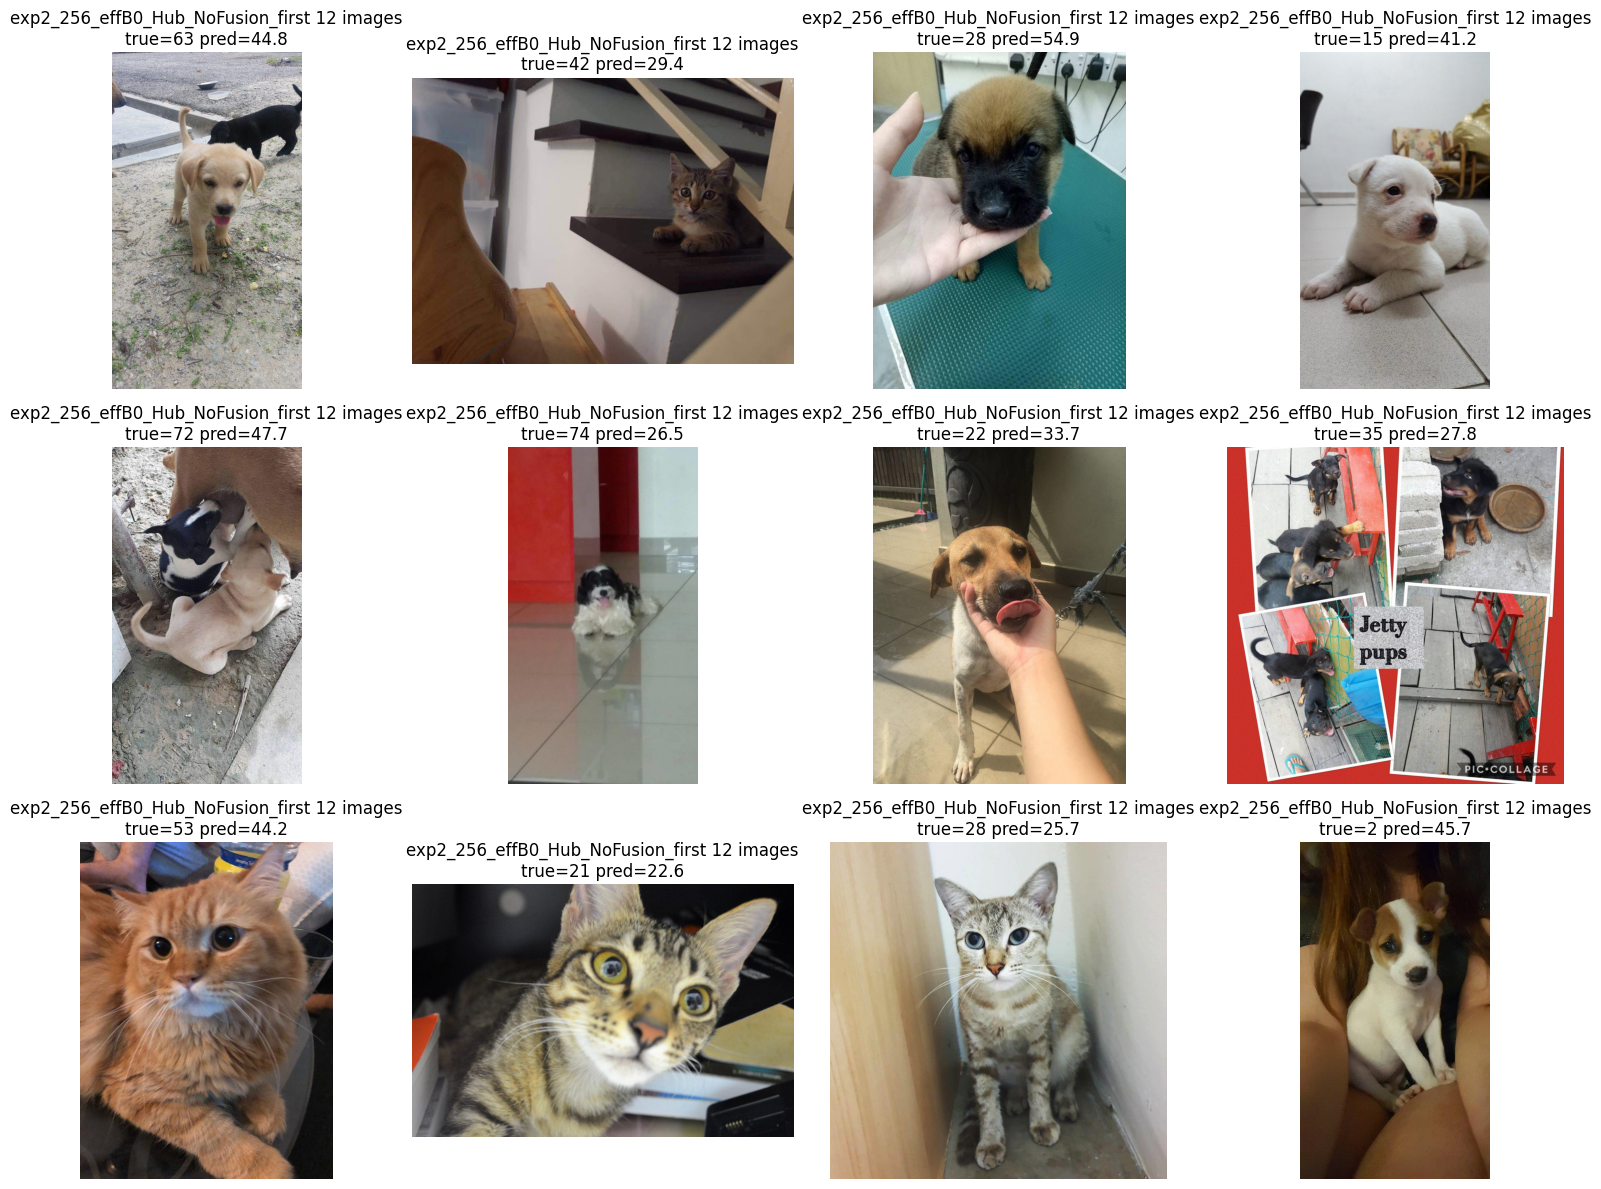

In [9]:

show_images_grid(oof_df, img_folder, n=12, title_prefix="exp2_256_effB0_Hub_NoFusion_first 12 images")